# Project: Data-driven Insights using Python: FoodHub Data Analysis



# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Importing the required libraries

In [ ]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Understanding the structure of the data

In [ ]:
# Import data set to google colab
from google.colab import files
uploaded = files.upload()
data = pd.read_csv("foodhub_order.csv")

Saving foodhub_order.csv to foodhub_order.csv


## Target Variable & Feature Classification

The goal of this analysis is to understand what factors influence
customer satisfaction on the FoodHub platform. The variable `rating`
serves as our proxy for customer satisfaction, as it directly captures
how the customer evaluated their order experience.

In [ ]:
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### Dataset Size

In [ ]:
data.shape

(1898, 9)

The dataset contains 1,898 orders across 9 variables.
This is a moderately sized dataset — enough to identify
patterns but small enough to explore fully.

### Data Types & Structure

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
data.isna().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
All 9 columns show 1,898 non-null values — no traditional missing
data. However, the `rating` column is stored as object instead of
numeric. After inspecting the raw data, I found entries with
"Not given" instead of a score. These will be converted to NaN
and the column cast to float before analysis.

### Handling Non-Numeric Values in Rating Column

In [ ]:
data['rating'] = data['rating'].replace('Not given', np.nan)
data['rating'] = data['rating'].astype(float)

* Before performing the univariate analysis on the rating variable, the "Not given" values were converted to NaN in order to treat them as missing values and allow proper numerical analysis.

### Duplicate Check

In [ ]:
data.duplicated().sum()

np.int64(0)

### Missing Values Analysis


In [ ]:
data.isna().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


In [ ]:
print('Percentage of missing ratings', round(736 / 1898 * 100),'%')

Percentage of missing ratings 39 %


#### Observations:
Only the `rating` column has missing values — 736 out of 1,898
orders (39%) were not rated. All other features are complete.

### Missing Value Treatment

Since this is an exploratory analysis (not predictive modeling),
missing ratings will not be imputed. Imputing would introduce
artificial customer opinions. Instead, rating-based analysis will
use only the 1,162 rated orders, while other analyses will use
the full dataset.

### Statistical Summary

In [ ]:
data.drop(columns=['order_id', 'customer_id']).describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1162.0,NaN,NaN,NaN,4.344234,0.741478,3.0,4.0,5.0,5.0,5.0
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:
- Shake Shack is the most frequent restaurant (219 orders out
  of 178 unique restaurants)
- American is the most popular cuisine type (584 orders out of
  14 cuisine types)
- Average order cost is 16.50 USD (range: 4.47 - 35.41 USD)
- Weekends have more orders than weekdays (1,351 vs 547)
- Rating count is 1,162 (confirms 736 missing), with a minimum
  of 3 and mean of 4.3 — relatively high satisfaction among
  those who rate
- Average food preparation time is ~27 min, average delivery
  time is ~24 min

# Exploratory Data Analysis (EDA)

## Univariate Analysis

In [ ]:
# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'muted'
sns.set_palette(PALETTE)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
COLORS = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B3']

In [ ]:
def plot_numerical(data, column, title):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(data[column], kde=True, ax=ax1)
    ax1.axvline(data[column].mean(), color='red', linestyle='--', label='Mean')
    ax1.axvline(data[column].median(), color='green', linestyle='--', label='Median')
    ax1.set_title(f'Distribution of {title}')
    ax1.legend()

    # Boxplot
    sns.boxplot(x=data[column], ax=ax2)
    ax2.set_title(f'Boxplot of {title}')

    plt.tight_layout()
    plt.show()

## Numerical Variables




### Rating

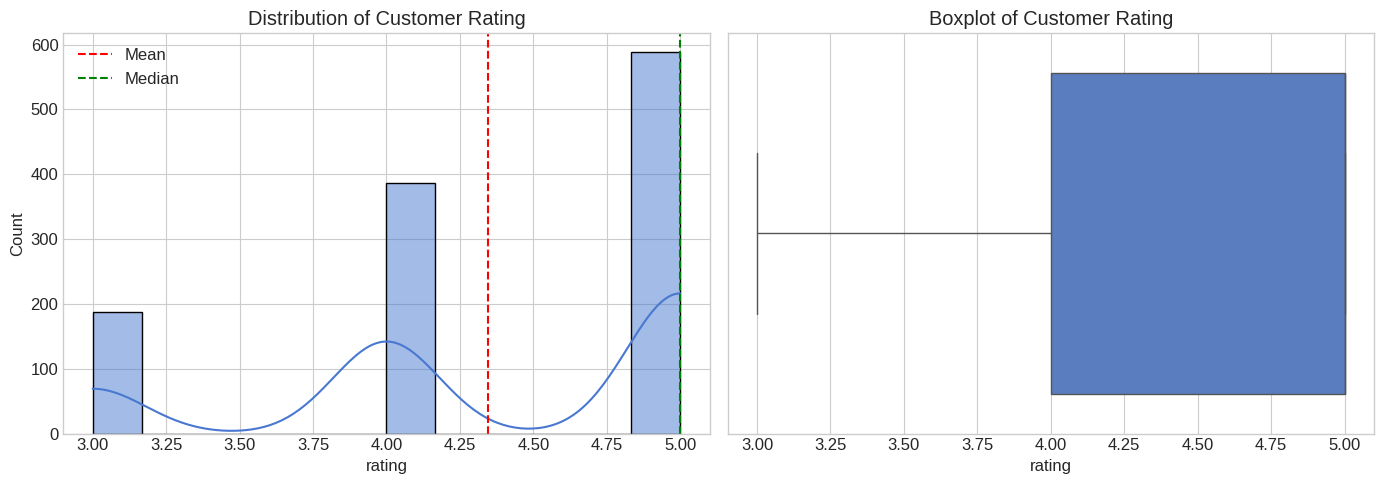

In [ ]:
plot_numerical(data,'rating', 'Customer Rating')

#### Observations:
Ratings are left-skewed (negatively skewed) with values only
between 3 and 5. The median is 5.0 while the mean is 4.3,
confirming the skew. The absence of ratings below 3 suggests
that dissatisfied customers tend not to leave ratings rather
than leaving low ones — a potential selection bias in our
target variable. The IQR (4-5) shows that most rated orders
reflect positive experiences.

### Cost of order

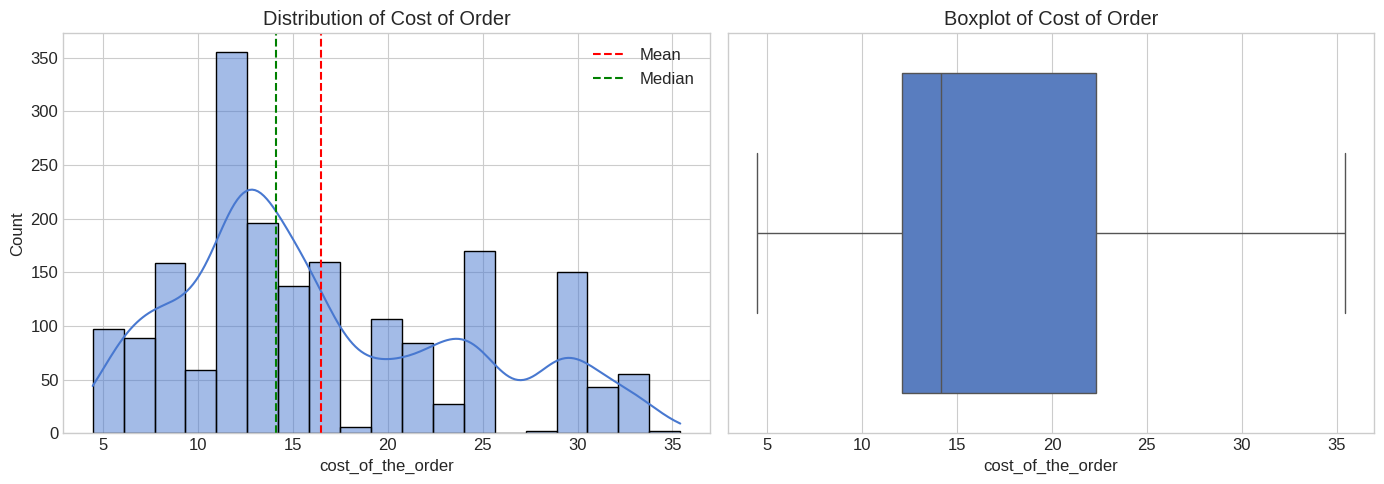

In [ ]:
plot_numerical(data,'cost_of_the_order', 'Cost of Order')

#### Observations:
Order cost is right-skewed (positively skewed) with mean
(16.50 USD) higher than median (14.14 USD), indicating some
higher-cost orders pull the average up. The IQR (12.08 - 22.30
USD) captures 50% of orders. No outliers are detected in the
boxplot. The maximum order is 35.41 USD, suggesting the
platform primarily serves mid-range restaurants.

### Food Preparation Time

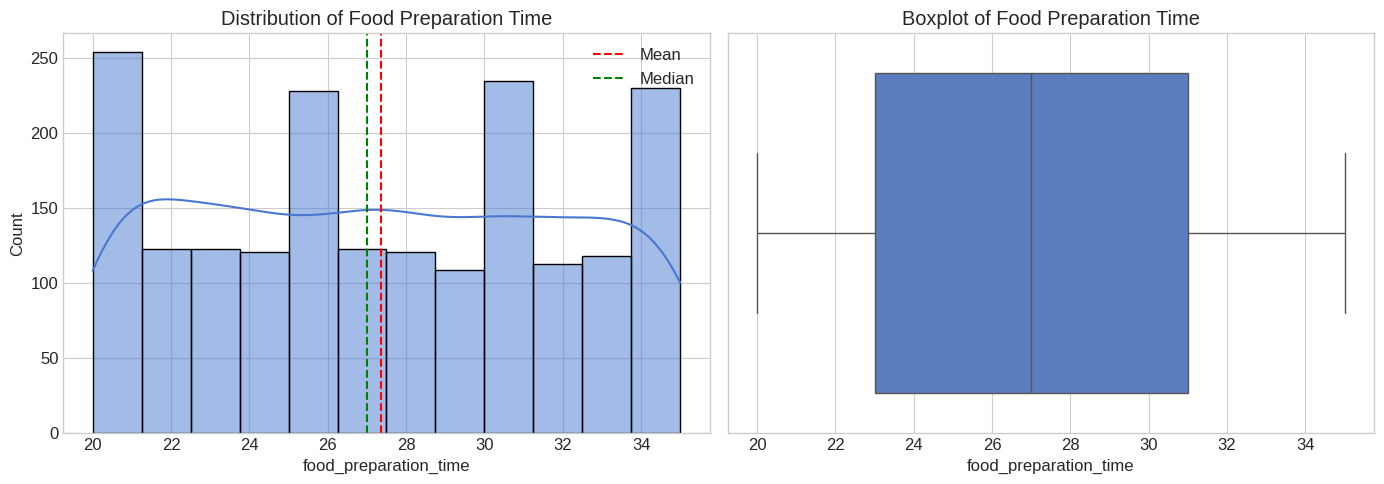

In [ ]:
plot_numerical(data,'food_preparation_time','Food Preparation Time')

#### Observations:
Food preparation time ranges from 20 to 35 minutes with mean
and median both at ~27 min, indicating a symmetric distribution.
However, the shape is closer to uniform than normal — orders
are roughly evenly spread across the range rather than
concentrated around the center. No outliers detected. The low
std (4.6 min) shows restaurants are fairly consistent in
preparation time.

### Delivery Time

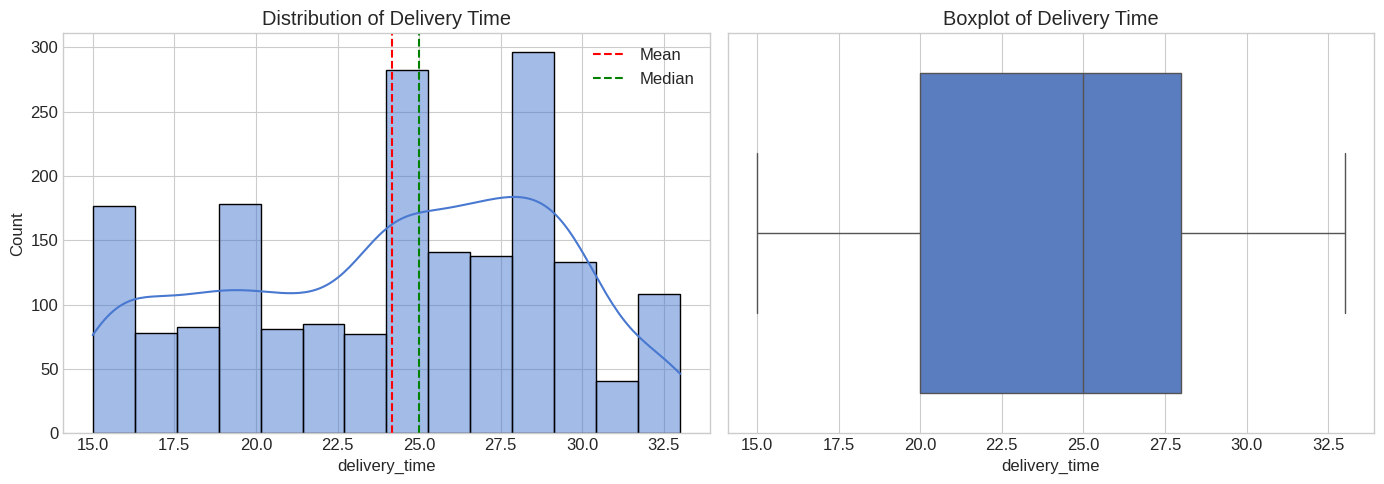

In [ ]:
plot_numerical(data,'delivery_time','Delivery Time')

#### Observations:
Delivery time ranges from 15 to 33 minutes. Mean (24 min)
and median (25 min) are very close, indicating a nearly
symmetric distribution with minimal skew. The IQR (20-28 min)
shows most deliveries are consistent. No outliers detected.
Std of 4.9 min represents moderate variation (~20% of the mean).

## Categorical Variables

In [ ]:

def plot_categorical(data, column, title, top_n=None):
    """Countplot with percentage labels for a categorical variable."""
    fig, ax = plt.subplots(figsize=(12, 6))

    if top_n:
        order = data[column].value_counts().head(top_n).index
    else:
        order = data[column].value_counts().index

    sns.countplot(data=data, x=column, order=order, ax=ax)
    ax.set_title(f'{title}')
    ax.set_xlabel('')

    # Add percentage labels on each bar
    total = len(data)
    for p in ax.patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Restaurant name

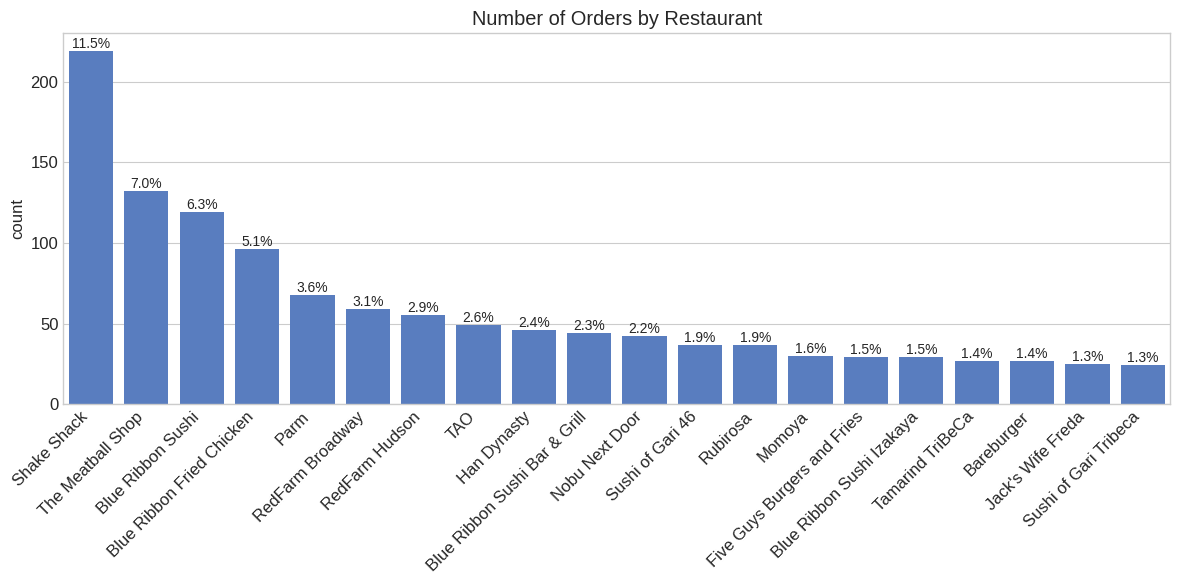

In [ ]:
plot_categorical(data, 'restaurant_name', 'Number of Orders by Restaurant', top_n=20)

#### Observations:
Shake Shack dominates with 11.5% of all orders — nearly double
the second place. The top 4 restaurants account for ~30% of
orders out of 178 total, showing high concentration. Multiple
"Blue Ribbon" brand locations appear in the top 20, suggesting
strong brand loyalty. A sharp drop-off after the top 5 indicates
a long-tail distribution — concentration risk if top restaurants
leave the platform.

### Cuisine Type

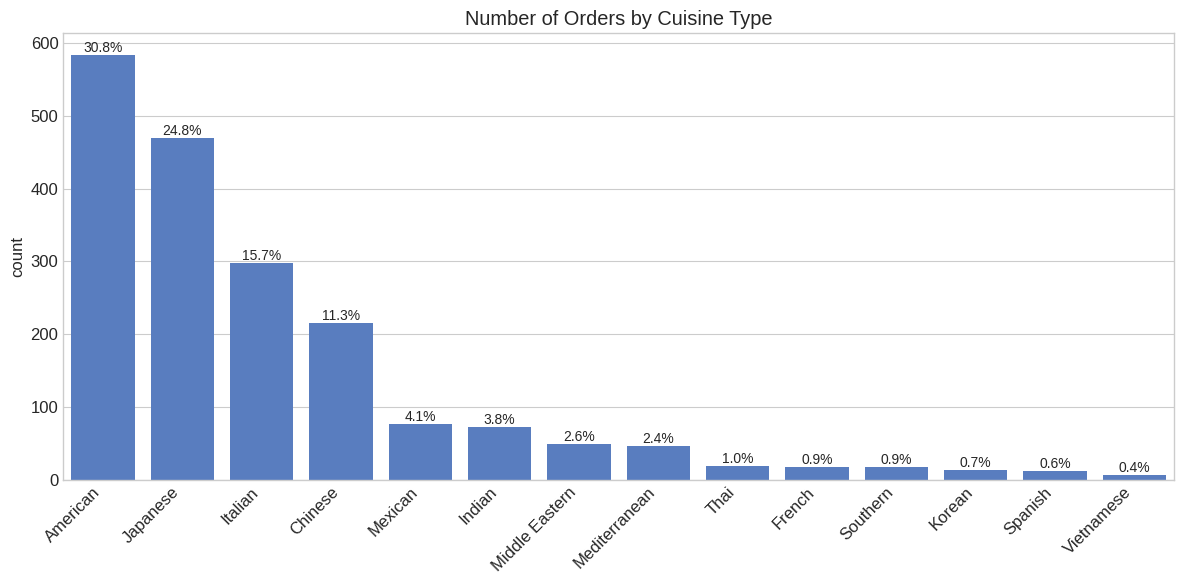

In [ ]:
plot_categorical(data, 'cuisine_type', 'Number of Orders by Cuisine Type', top_n=20)

#### Observations:
The top 4 cuisines (American, Japanese, Italian, Chinese)
represent ~83% of all orders out of 14 cuisine types. American
alone accounts for 30.8%. A sharp drop-off after Chinese
suggests the remaining 10 cuisines are niche categories on the
platform. Worth investigating whether American dominance is due
to more restaurants or higher orders per restaurant.

### Day of the Week


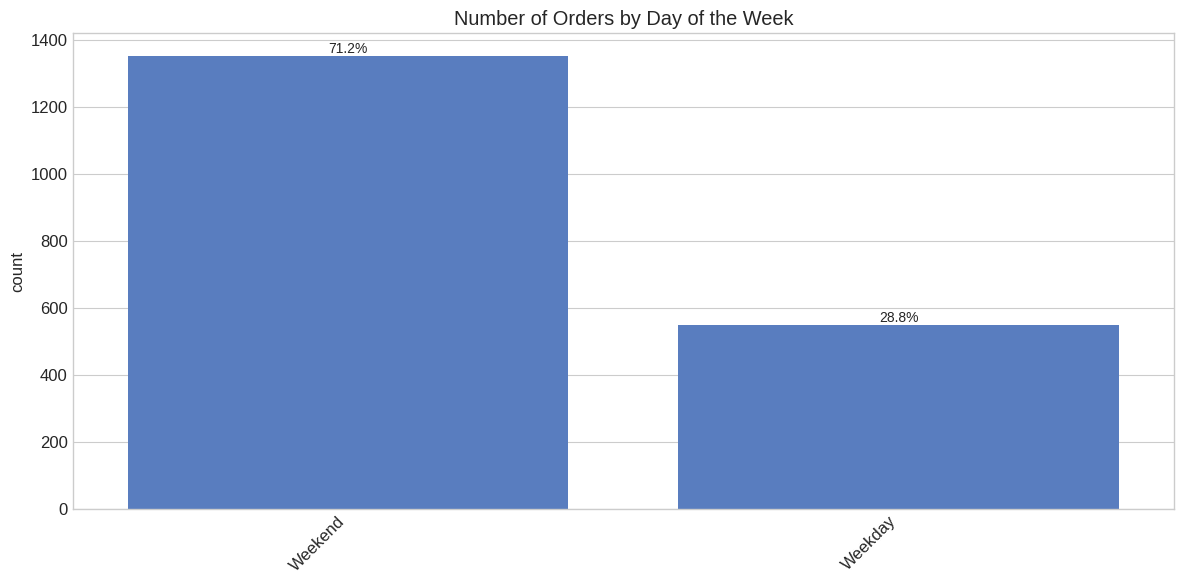

In [ ]:
plot_categorical(data, 'day_of_the_week', 'Number of Orders by Day of the Week')

#### Observations:
Weekends account for 71.2% of orders vs 28.8% on weekdays —
a 2.5:1 ratio. However, weekends are only 2 days vs 5 weekdays,
so the per-day order rate on weekends is roughly 6x higher than
weekdays. This suggests FoodHub should allocate significantly
more delivery resources on weekends.

## Multivariate Analysis

### Numerical Variables

#Heatmap


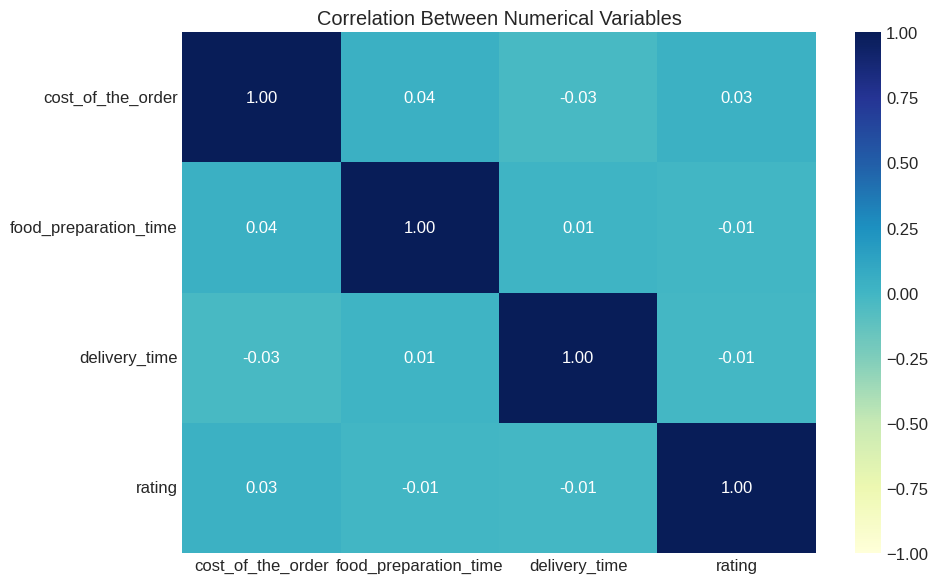

In [ ]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(10, 6))
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
sns.heatmap(data[numerical_cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='YlGnBu',
            center=0,
            vmin=-1,
            vmax=1)
plt.title('Correlation Between Numerical Variables')
plt.tight_layout()
plt.show()

#### Observations
* The correlation heatmap shows that there are no strong linear relationships between the numerical variables in the dataset. All correlation values are very close to zero, indicating weak or negligible associations. This suggests that order cost, preparation time, delivery time, and rating operate independently from one another in this dataset.

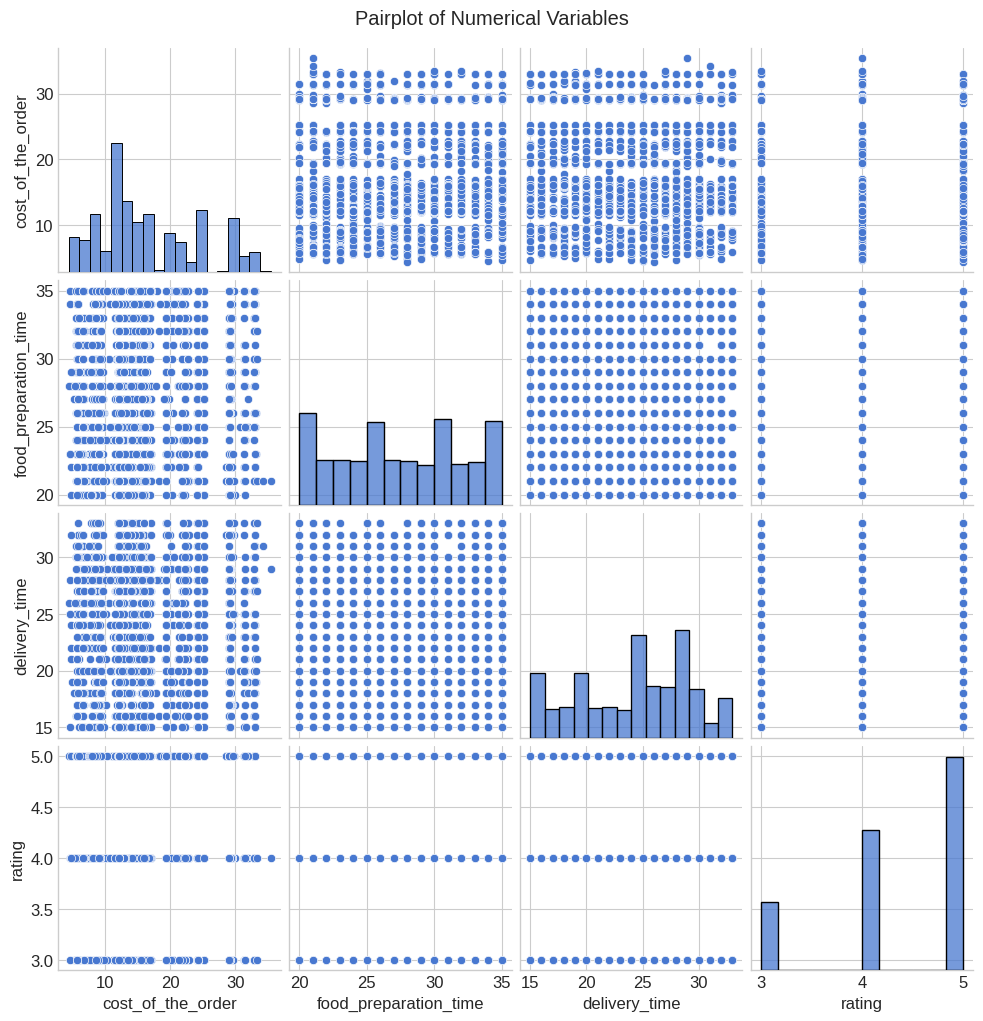

In [ ]:
sns.pairplot(data[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']])
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

#### Observations:
Pairplot confirms heatmap findings — no visible linear
relationships between numerical variables. Scatterplots
show random dispersion with no clear patterns.

## Numerical vs Categorical Variables

In [ ]:
def plot_boxplot(data, num_col, cat_col, title, top_n=None):
    """Boxplot: numerical vs categorical."""
    fig, ax = plt.subplots(figsize=(12, 6))
    if top_n:
        order = data[cat_col].value_counts().head(top_n).index
        plot_data = data[data[cat_col].isin(order)]
    else:
        order = data[cat_col].value_counts().index
        plot_data = data
    sns.boxplot(data=plot_data, x=cat_col, y=num_col, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Ratings vs Cuisine Type

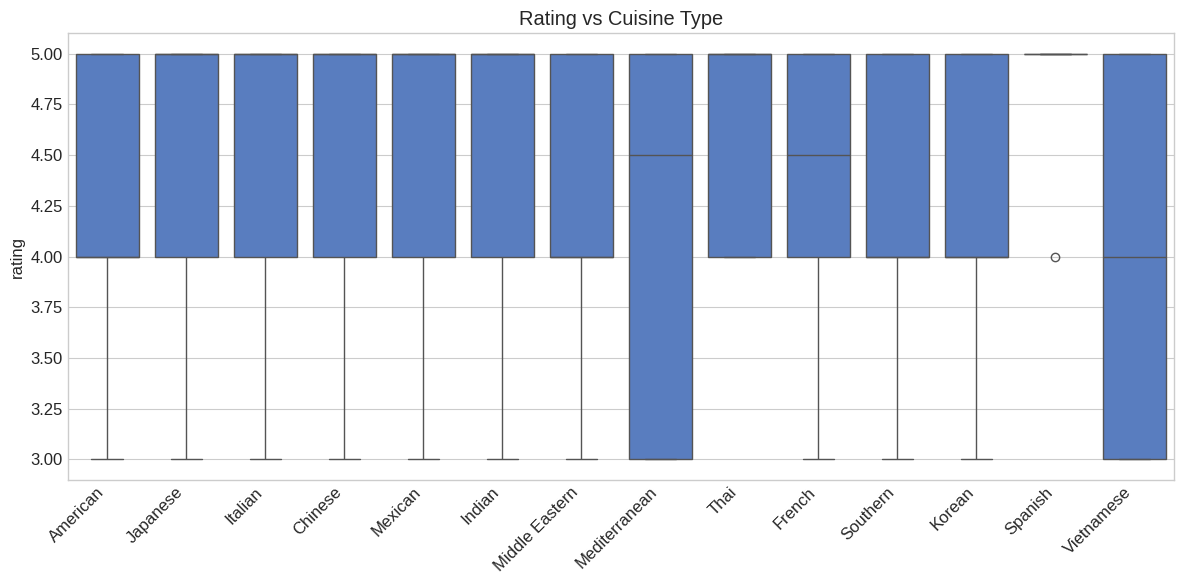

In [ ]:
plot_boxplot(data, 'rating', 'cuisine_type', 'Rating vs Cuisine Type')

#### Observations:
Rating distributions are very similar across cuisine types
due to the limited range (3-5). Most cuisines show a median
of 5 with the same IQR. Mediterranean and Vietnamese show
slightly lower medians but have very few orders, making those
differences unreliable. Conclusion: cuisine type alone does
not appear to differentiate customer satisfaction.

#### Rating vs Restaurant Name

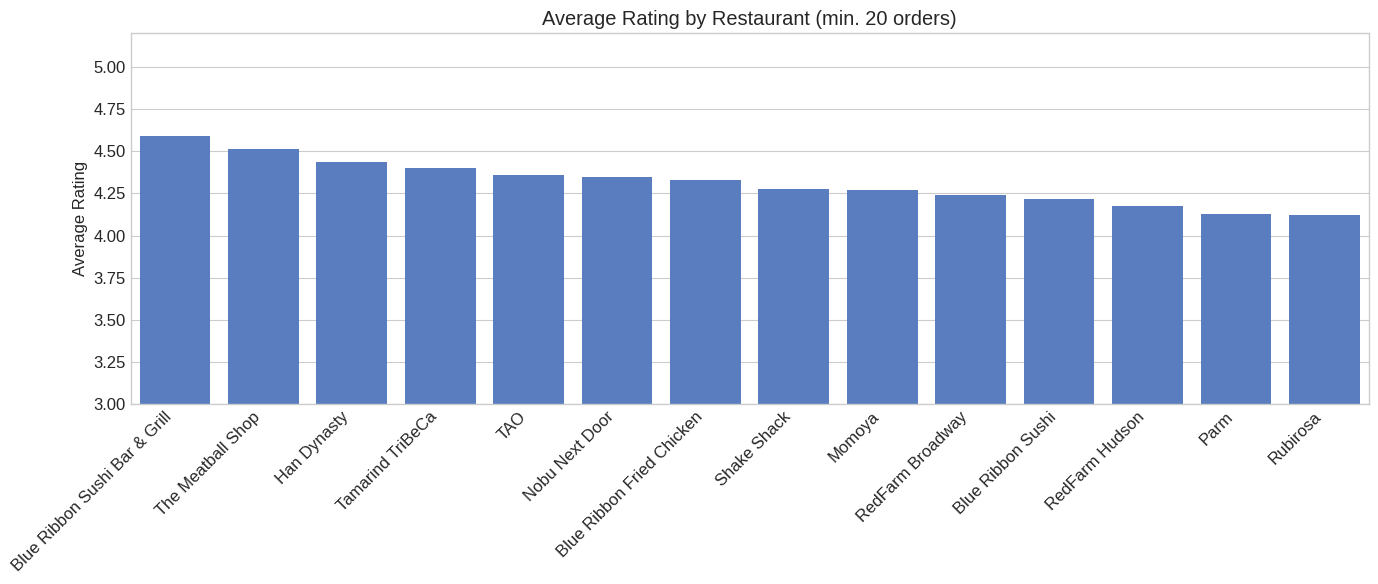

In [ ]:
# Filter restaurants with at least 20 orders for reliable averages
restaurant_ratings = data.groupby('restaurant_name')['rating'].agg(['mean', 'count'])
restaurant_ratings = restaurant_ratings[restaurant_ratings['count'] >= 20].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(x=restaurant_ratings.index, y=restaurant_ratings['mean'], ax=ax)
ax.set_title('Average Rating by Restaurant (min. 20 orders)')
ax.set_ylabel('Average Rating')
ax.set_xlabel('')
ax.set_ylim(3, 5.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
data.groupby('restaurant_name')['rating'].agg(['mean','median', 'count']).query('count > 50').sort_values('mean', ascending=False).head(20)

,mean,median,count
restaurant_name,,,
The Meatball Shop,4.511905,5.0,84
Blue Ribbon Fried Chicken,4.328125,4.5,64
Shake Shack,4.278195,4.0,133
Blue Ribbon Sushi,4.219178,4.0,73


All restaurants with 20+ orders score between 4.1 and 4.6 —
a narrow 0.5-point range. This confirms what we saw in the
cuisine analysis: ratings are consistently high regardless of
restaurant. Notably, Shake Shack (highest order volume at
11.5%) ranks mid-pack in satisfaction, while Blue Ribbon
Sushi Bar & Grill leads in rating but with fewer orders.
High volume does not guarantee highest satisfaction.

### Ratings vs Day of the Week

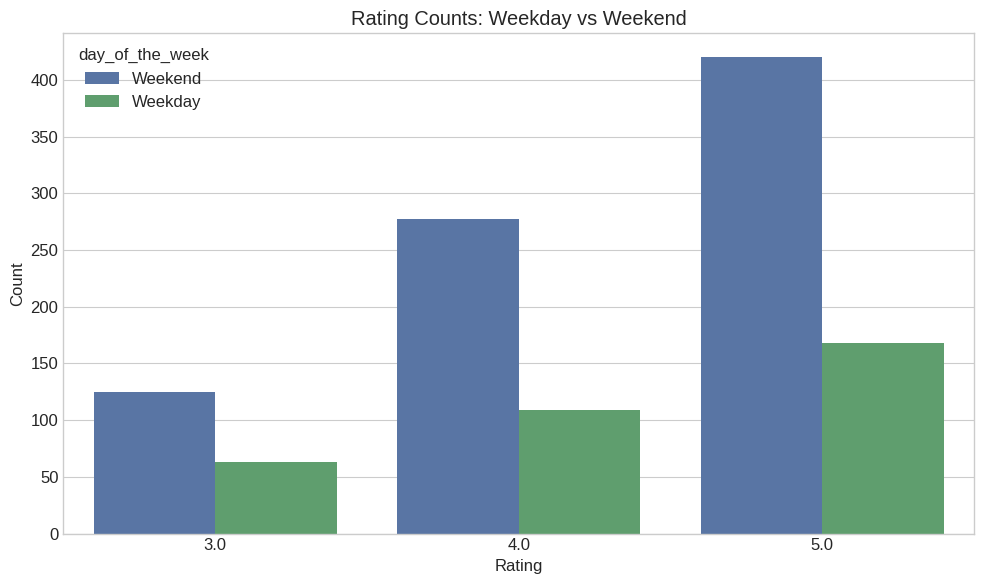

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=data, x='rating', hue='day_of_the_week',
              palette=['#4C72B0', '#55A868'], ax=ax)
ax.set_title('Rating Counts: Weekday vs Weekend')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
data.groupby('day_of_the_week')['rating'].agg(['mean','median', 'count'])

,mean,median,count
day_of_the_week,,,
Weekday,4.308824,4.0,340
Weekend,4.358881,5.0,822


#### Observations:
While weekends show higher raw counts across all ratings
(due to higher order volume), the proportions are nearly
identical — both weekdays and weekends show ~50% five-star
and ~15-19% three-star ratings. Day of the week does not
meaningfully affect customer satisfaction.

### Cost of Order vs Cuisine Type

/tmp/ipykernel_1611/1699136858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='cuisine_type', y='cost_of_the_order',
/tmp/ipykernel_1611/1699136858.py:4: UserWarning: The palette list has more values (15) than needed (14), which may not be intended.
  sns.boxplot(data=data, x='cuisine_type', y='cost_of_the_order',


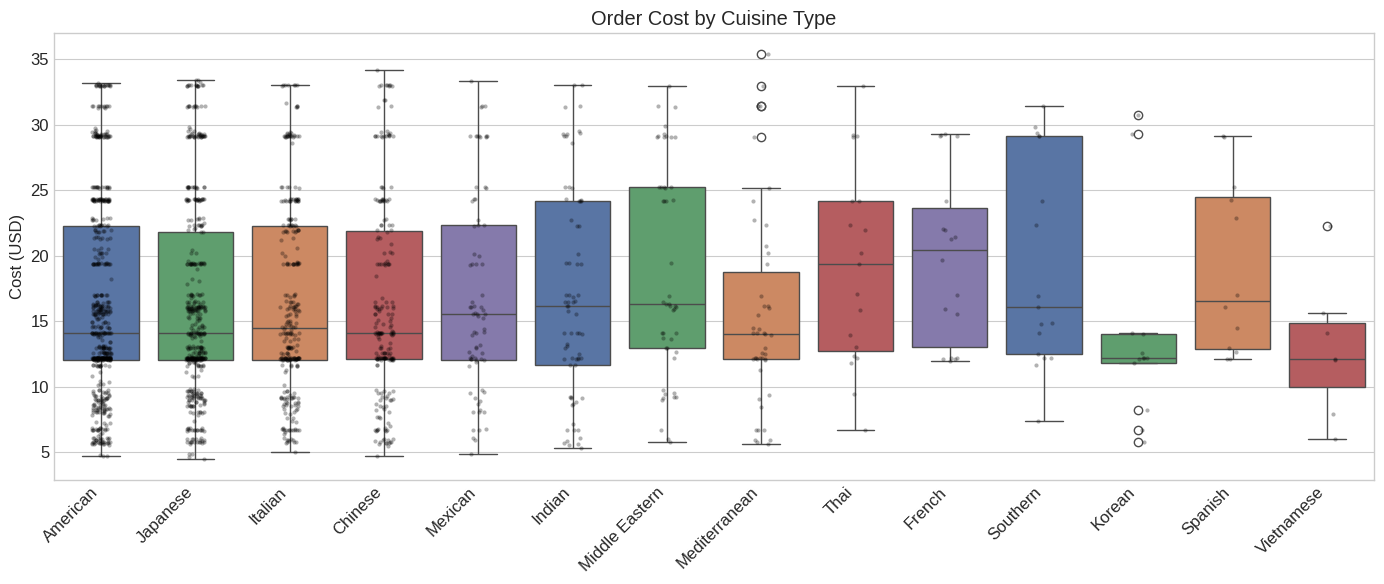

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
order = data['cuisine_type'].value_counts().index

sns.boxplot(data=data, x='cuisine_type', y='cost_of_the_order',
            order=order, palette=COLORS * 3, ax=ax)
sns.stripplot(data=data, x='cuisine_type', y='cost_of_the_order',
              order=order, color='black', alpha=0.3, size=3, ax=ax)

ax.set_title('Order Cost by Cuisine Type')
ax.set_xlabel('')
ax.set_ylabel('Cost (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observations:
The top 5 cuisines (American, Japanese, Italian, Chinese, Mexican)
show similar cost distributions with medians around 14-15 USD.
However, some niche cuisines show higher prices — Southern and
Middle Eastern have higher medians (20-25 USD), while Korean
is the cheapest (13 USD). Mediterranean shows the most outliers
at the high end. The strip overlay reveals that most orders
across all cuisines cluster in the 10-22 USD range regardless
of type.

#### Delivery Time vs Day of the week

/tmp/ipykernel_1611/3253094263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='day_of_the_week', y='delivery_time',


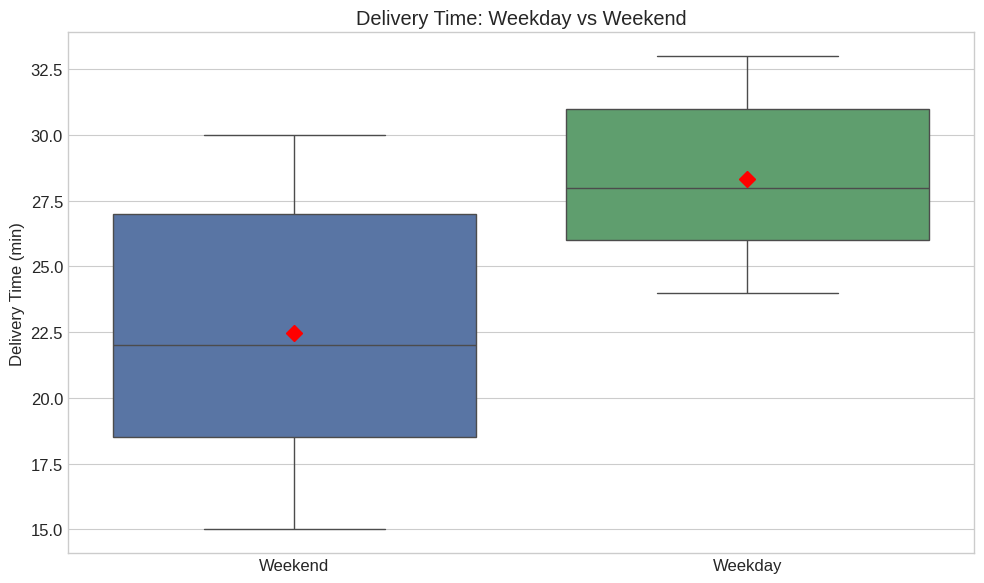

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=data, x='day_of_the_week', y='delivery_time',
            palette=['#4C72B0', '#55A868'], ax=ax,
            showmeans=True,
            meanprops={'marker':'D', 'markerfacecolor':'red',
                       'markeredgecolor':'red', 'markersize':8})
ax.set_title('Delivery Time: Weekday vs Weekend')
ax.set_xlabel('')
ax.set_ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

In [ ]:
data.groupby('day_of_the_week')['delivery_time'].agg(['mean','median', 'count'])

,mean,median,count
day_of_the_week,,,
Weekday,28.340037,28.0,547
Weekend,22.470022,22.0,1351


#### Observations:
Weekday deliveries take significantly longer (mean 28.3 min,
median 28) than weekends (mean 22.5 min, median 22) — a 6-minute
difference. This is counterintuitive since weekends handle 2.5x
more orders. Possible explanations: more delivery drivers
scheduled on weekends, less traffic on weekends, or shorter
delivery distances. This is one of the strongest findings —
FoodHub should investigate why weekday operations are slower
despite lower volume.

### Delivery Time vs Day of Week

/tmp/ipykernel_1611/3535871302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='day_of_the_week', y='food_preparation_time',


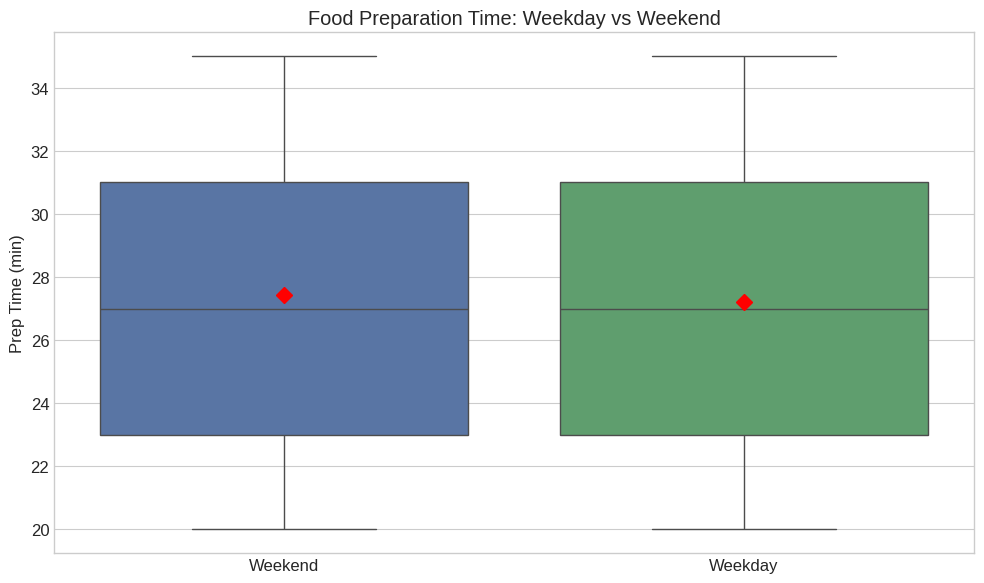

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=data, x='day_of_the_week', y='food_preparation_time',
            palette=['#4C72B0', '#55A868'], ax=ax,
            showmeans=True,
            meanprops={'marker':'D', 'markerfacecolor':'red',
                       'markeredgecolor':'red', 'markersize':8})
ax.set_title('Food Preparation Time: Weekday vs Weekend')
ax.set_xlabel('')
ax.set_ylabel('Prep Time (min)')
plt.tight_layout()
plt.show()

In [ ]:
data.groupby('day_of_the_week')['food_preparation_time'].agg(['mean','median','count']).sort_values('count', ascending=False)

,mean,median,count
day_of_the_week,,,
Weekend,27.436714,27.0,1351
Weekday,27.212066,27.0,547


#### Observations:
Prep time is nearly identical between weekdays (mean 27.2 min)
and weekends (mean 27.4 min). Combined with the delivery time
finding (weekdays 6 min slower), this confirms the bottleneck
is NOT in the kitchen — it's in the delivery logistics. FoodHub
should investigate weekday delivery operations: possible causes
include fewer drivers, higher traffic, or longer distances.

#### Cusine vs Preparation Time

/tmp/ipykernel_1611/4151472276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='cuisine_type', y='food_preparation_time',
/tmp/ipykernel_1611/4151472276.py:4: UserWarning: The palette list has more values (15) than needed (14), which may not be intended.
  sns.boxplot(data=data, x='cuisine_type', y='food_preparation_time',


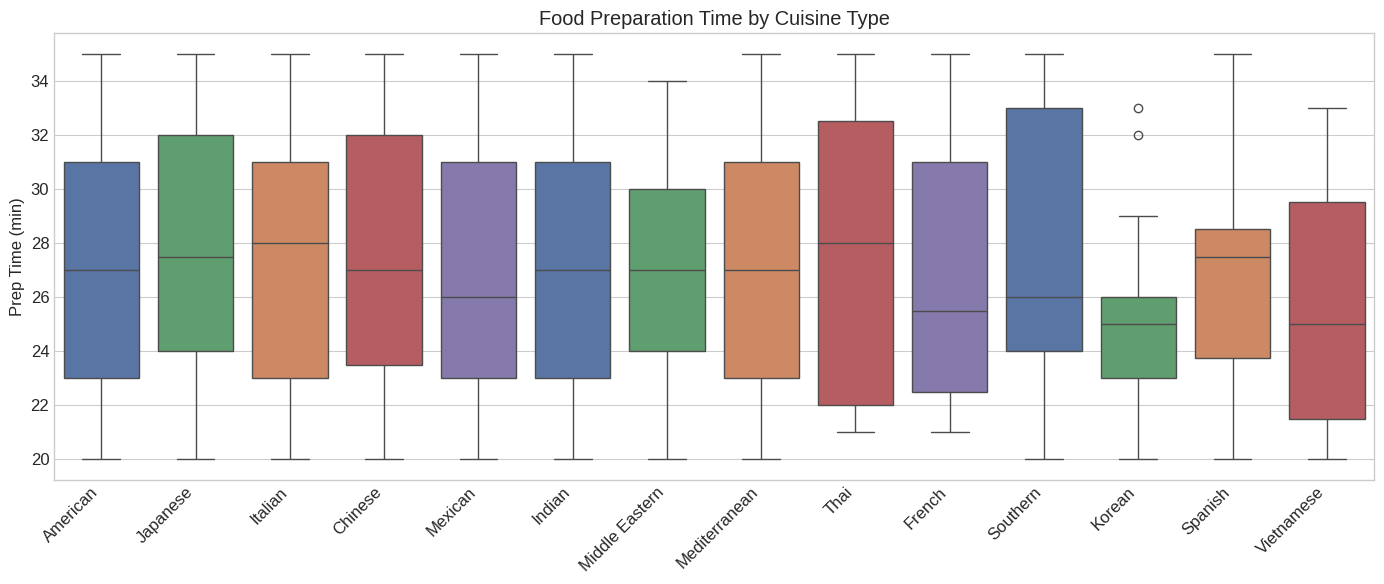

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
order = data['cuisine_type'].value_counts().index

sns.boxplot(data=data, x='cuisine_type', y='food_preparation_time',
            order=order, palette=COLORS * 3, ax=ax)
ax.set_title('Food Preparation Time by Cuisine Type')
ax.set_xlabel('')
ax.set_ylabel('Prep Time (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
data.groupby('cuisine_type')['food_preparation_time'].agg(['mean','median', 'count']).sort_values('count', ascending=False)

,mean,median,count
cuisine_type,,,
American,27.440068,27.0,584
Japanese,27.510638,27.5,470
Italian,27.483221,28.0,298
Chinese,27.511628,27.0,215
Mexican,26.727273,26.0,77
Indian,27.109589,27.0,73
Middle Eastern,26.673469,27.0,49
Mediterranean,27.000000,27.0,46
Thai,27.315789,28.0,19


#### Observations:
Food preparation time is remarkably consistent across all
cuisine types — means range from 25.5 to 27.5 min, only a
2-minute difference. Even with significant class imbalance
(American: 584 orders vs Vietnamese: 7), the distributions
remain similar. Cuisine type does not meaningfully affect
preparation time, suggesting FoodHub's restaurants operate
within a standardized prep window regardless of food type.

## Categorical vs Categorical Variables

### Cuisine Type vs Day of the Week

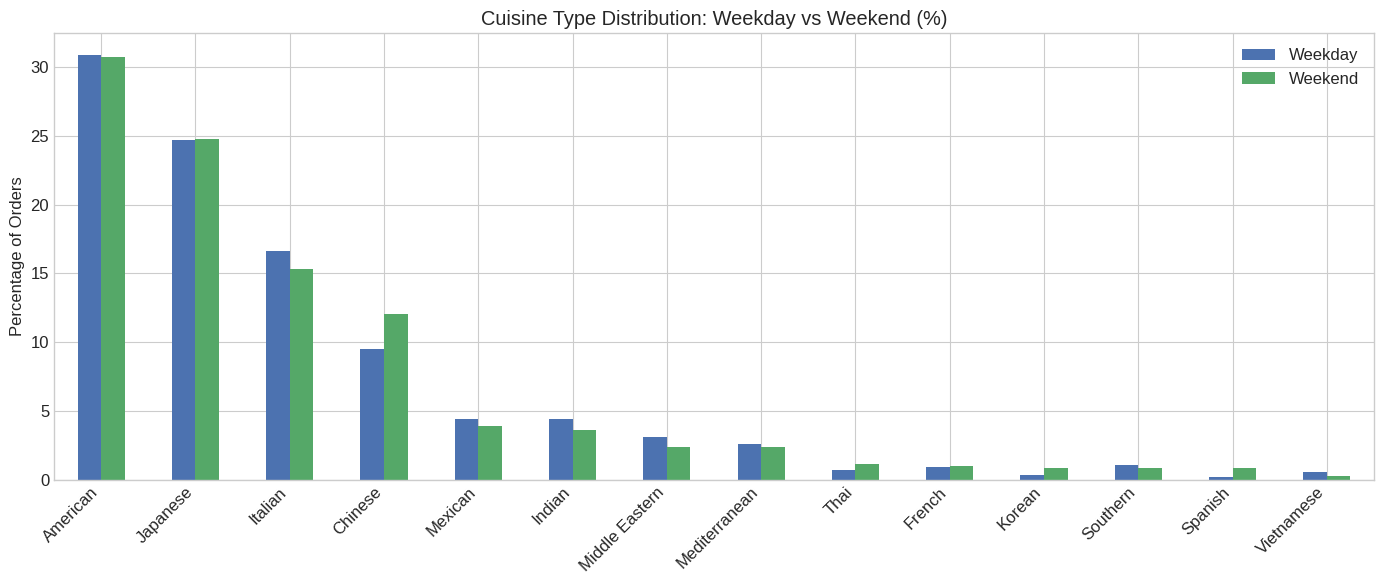

In [ ]:

ct = pd.crosstab(data['cuisine_type'], data['day_of_the_week'], normalize='columns') * 100
ct = ct.sort_values('Weekend', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868'])
ax.set_title('Cuisine Type Distribution: Weekday vs Weekend (%)')
ax.set_xlabel('')
ax.set_ylabel('Percentage of Orders')
plt.xticks(rotation=45, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.show()

#### Observations:
Cuisine preferences remain consistent regardless of day —
proportions are nearly identical between weekdays and weekends
across all cuisine types. Customers order the same type of
food whether it's Tuesday or Saturday. FoodHub does not need
day-specific cuisine promotions.

## Feature Engineering

### Creating Total Order Time Variable

In [ ]:
data['total_time'] = data['food_preparation_time'] + data['delivery_time']

### Distribution of Total Order Time

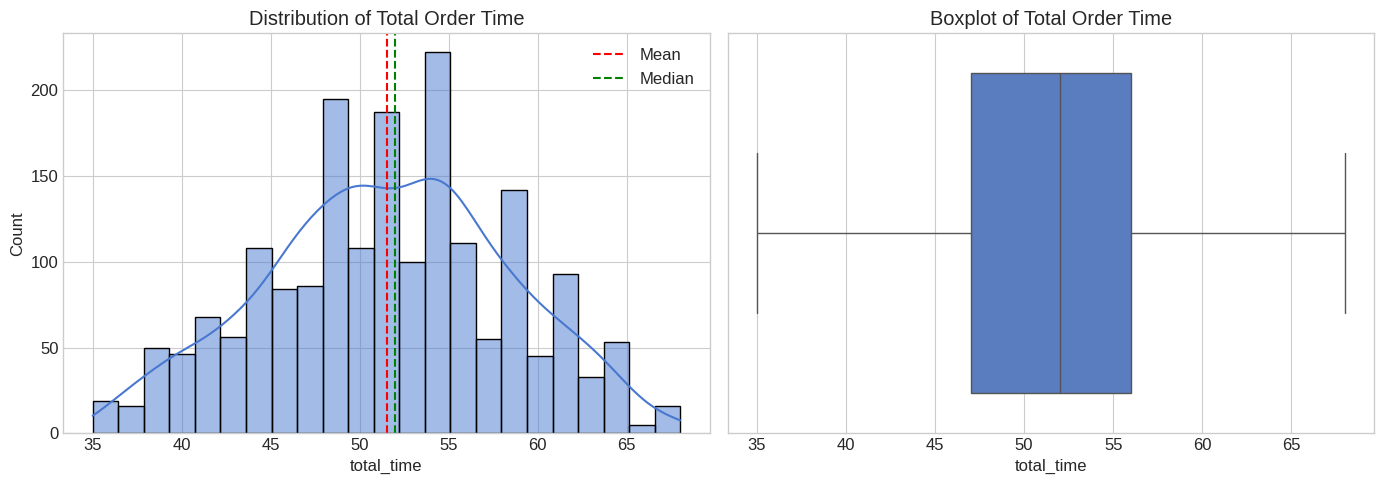

In [ ]:
plot_numerical(data, 'total_time', 'Total Order Time')

In [ ]:
data['total_time'].describe().T

,total_time
count,1898.000000
mean,51.533720
std,6.833603
min,35.000000
25%,47.000000
50%,52.000000
75%,56.000000
max,68.000000


#### Observations:
Total order time follows a roughly normal distribution with
mean and median both around 51 min. The IQR (45-57 min) shows
most orders complete within an hour.

### Total Order Time vs Day of Week

/tmp/ipykernel_1611/5789539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='day_of_the_week', y='total_time',


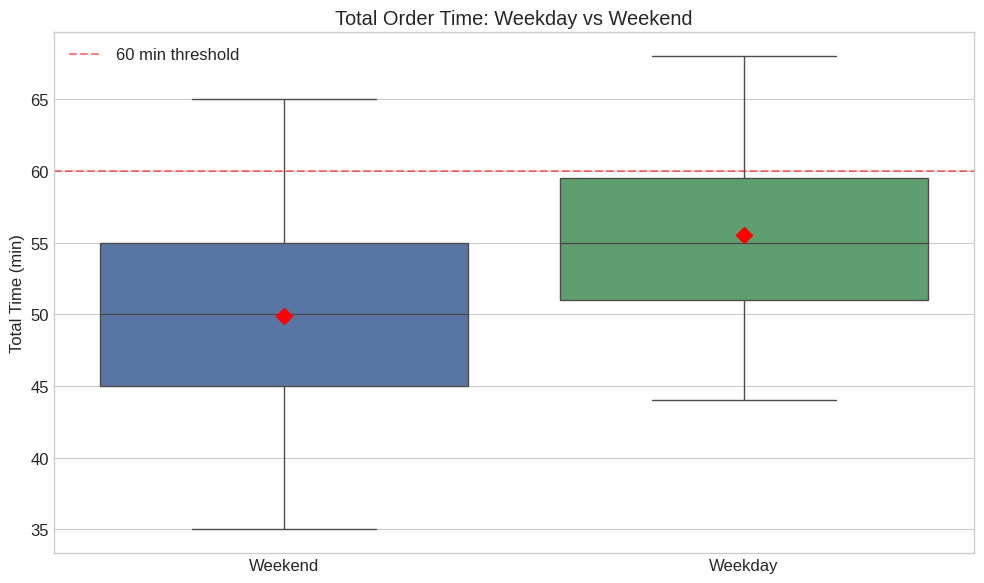

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=data, x='day_of_the_week', y='total_time',
            palette=['#4C72B0', '#55A868'], ax=ax,
            showmeans=True,
            meanprops={'marker':'D', 'markerfacecolor':'red',
                       'markeredgecolor':'red', 'markersize':8})
ax.set_title('Total Order Time: Weekday vs Weekend')
ax.set_xlabel('')
ax.set_ylabel('Total Time (min)')
ax.axhline(y=60, color='red', linestyle='--', alpha=0.5, label='60 min threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
data.groupby('day_of_the_week')['total_time'].agg(['mean','median', 'count']).sort_values('count', ascending=False)

,mean,median,count
day_of_the_week,,,
Weekend,49.906736,50.0,1351
Weekday,55.552102,55.0,547


#### Observations:
Total order time confirms the delivery time pattern — weekday
orders average 55.5 min (median 55) vs weekend 49.9 min
(median 50), a 5-6 minute gap. Weekday orders approach the
60-min threshold, with the Q3 reaching 60 min — meaning 25%
of weekday orders take over an hour. Since prep time was
identical between days, the entire gap comes from delivery
logistics. This is the strongest actionable finding: FoodHub
needs to improve weekday delivery operations.

### Total Order Time vs Ratings


In [ ]:
# Correlation
data[['total_time', 'rating']].corr()

,total_time,rating
total_time,1.000000,-0.011348
rating,-0.011348,1.000000


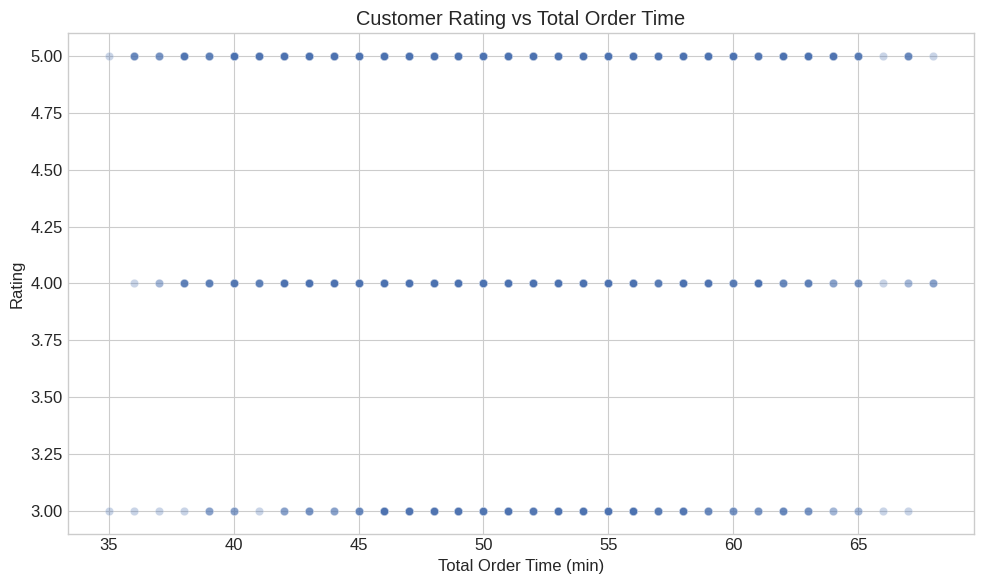

In [ ]:
# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=data, x='total_time', y='rating',
                alpha=0.3, color='#4C72B0', ax=ax)
ax.set_title('Customer Rating vs Total Order Time')
ax.set_xlabel('Total Order Time (min)')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.show()

#### Observations:
Correlation between total order time and rating is -0.01 —
virtually zero. The scatter plot confirms no identifiable
pattern. Surprisingly, even orders taking 65+ min receive
5-star ratings. This reinforces our earlier finding: customers
who are dissatisfied likely don't rate at all rather than
leaving low scores.

# Conclusion and Business Recommendations

## Key Findings

1. **Selection bias in ratings**: 39% of orders are unrated, and
   existing ratings only range 3-5. No scores of 1-2 suggest
   dissatisfied customers don't rate rather than rating low.

2. **Weekday delivery bottleneck**: Deliveries take 6 min longer
   on weekdays (28.3 vs 22.5 min) despite 2.5x fewer orders.
   Prep time is identical across days, confirming the issue is
   delivery logistics, not the kitchen.

3. **25% of weekday orders exceed 60 min total time**, compared
   to significantly fewer on weekends.

4. **High restaurant concentration**: Top 4 restaurants handle
   30% of all orders out of 178. Shake Shack alone accounts
   for 11.5%.

5. **Weekend dominance**: 71% of orders occur on weekends —
   roughly 6x the per-day rate of weekdays.

6. **No numerical feature correlates with rating**: Cost, prep
   time, delivery time, and total time show near-zero correlation
   with customer satisfaction. You are correct — the factors
   driving ratings are not captured in this dataset.

7. **Consistency across cuisines**: Prep time, cost, and ratings
   are similar across all cuisine types. Preferences don't
   change between weekdays and weekends.

## Business Recommendations

1. **Capture dissatisfied customer feedback**: Implement incentives
   (discount on next order, loyalty points) for customers to rate
   their experience, especially after negative ones. Currently 39%
   of orders go unrated, likely hiding dissatisfaction data that
   could reveal what drives bad experiences on the platform.

2. **Investigate weekday delivery delays**: Weekday deliveries take
   6 min longer despite lower volume. Analyze driver availability,
   traffic patterns, and delivery distances on weekdays to identify
   and fix the bottleneck.

3. **Boost weekday demand**: Introduce weekday-specific promotions
   (discounts, free delivery, combo deals) to redistribute order
   volume — weekends currently handle 71% of orders, leaving
   weekday capacity underutilized.

4. **Diversify restaurant participation**: Support lower-performing
   restaurants with marketing tools, featured placements, or
   co-branded promotions. The top 4 restaurants capture 30% of
   orders — reducing this concentration protects the platform if
   a top restaurant leaves.

## Limitations & Next Steps

- Rating scale (3-5 only) limits satisfaction analysis —
  binary rated/unrated may be more informative.
- No geographic data to analyze delivery distances.
- No timestamp granularity (hour of day) to identify peak periods.
- Next step: predictive model to classify whether a customer
  will rate or not, using the available features.